In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Configurar matplotlib para visualizaciones en español
plt.rcParams['font.size'] = 10

In [2]:
# ============================================
# 1. DEFINIR LA ARQUITECTURA DEL AUTOENCODER
# ============================================

class Autoencoder(nn.Module):
    def __init__(self, input_dim=4, latent_dim=2):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )
    
    def forward(self, x):
        # Codificar
        latent = self.encoder(x)
        # Decodificar
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Crear instancia del modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

model = Autoencoder(input_dim=4, latent_dim=2).to(device)
print(f"\nModelo:\n{model}")

Dispositivo: cpu

Modelo:
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=4, bias=True)
  )
)


In [3]:
# ============================================
# 2. PREPARAR LOS DATOS
# ============================================

# Cargar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Agregar outliers artificiales (flores con características extremas)
np.random.seed(42)
num_outliers = 10
outliers = np.random.uniform(-4, 4, size=(num_outliers, 4))

# Combinar datos normales con outliers
X_with_outliers = np.vstack([X_scaled, outliers])
y_labels = np.hstack([np.zeros(len(X_scaled)), np.ones(num_outliers)])  # 0: normal, 1: outlier

# Convertir a tensores de PyTorch
X_tensor = torch.FloatTensor(X_with_outliers).to(device)
y_tensor = torch.LongTensor(y_labels)

# Crear DataLoader (usando solo datos de entrenamiento)
dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Datos de entrenamiento: {X_tensor.shape}")
print(f"Etiquetas: {y_tensor.shape}")
print(f"Número de outliers: {num_outliers}")

Datos de entrenamiento: torch.Size([160, 4])
Etiquetas: torch.Size([160])
Número de outliers: 10


Entrenando el autoencoder...
Época 20/100, Pérdida: 0.9658
Época 40/100, Pérdida: 0.2829
Época 60/100, Pérdida: 0.2147
Época 80/100, Pérdida: 0.1930
Época 100/100, Pérdida: 0.1677
¡Entrenamiento completado!


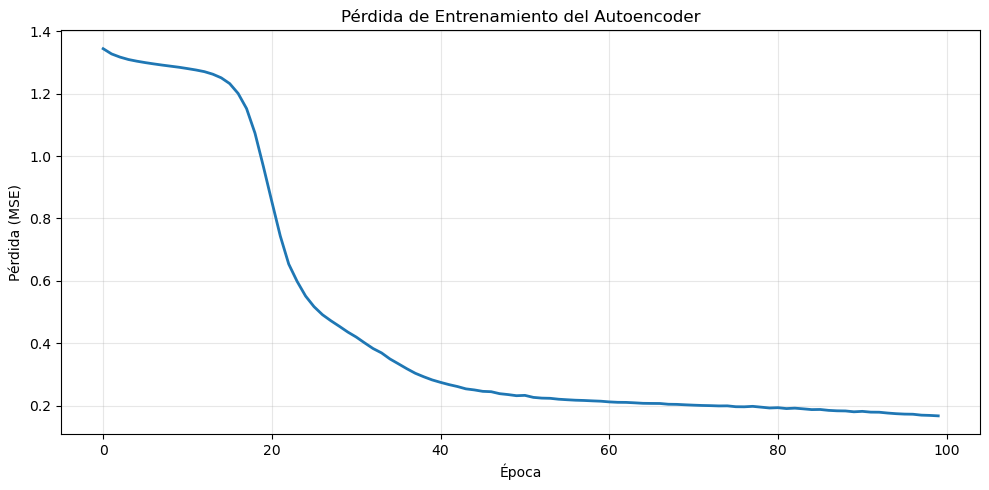

In [4]:
# ============================================
# 3. ENTRENAR EL AUTOENCODER
# ============================================

# Hiperparámetros
epochs = 100
learning_rate = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Almacenar pérdidas
train_losses = []

# Entrenar
print("Entrenando el autoencoder...")
for epoch in range(epochs):
    total_loss = 0
    for batch_X, _ in train_loader:
        # Forward pass
        reconstructed, _ = model(batch_X)
        loss = criterion(reconstructed, batch_X)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    train_losses.append(total_loss / len(train_loader))
    
    if (epoch + 1) % 20 == 0:
        print(f"Época {epoch + 1}/{epochs}, Pérdida: {train_losses[-1]:.4f}")

print("¡Entrenamiento completado!")

# Visualizar la pérdida de entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(train_losses, linewidth=2)
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.title('Pérdida de Entrenamiento del Autoencoder')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ============================================
# 4. DETECTAR OUTLIERS
# ============================================

# Pasar todos los datos a través del modelo
model.eval()
with torch.no_grad():
    reconstructed_all, latent_all = model(X_tensor)

# Calcular el error de reconstrucción (MSE) para cada muestra
reconstruction_errors = torch.mean((X_tensor - reconstructed_all) ** 2, dim=1).cpu().numpy()

print(f"Error de reconstrucción - Min: {reconstruction_errors.min():.4f}, "
      f"Max: {reconstruction_errors.max():.4f}, "
      f"Media: {reconstruction_errors.mean():.4f}")

# Calcular umbral (percentil 95 de los datos normales)
normal_errors = reconstruction_errors[y_labels == 0]
threshold = np.percentile(normal_errors, 95)
print(f"Umbral de detección (percentil 95): {threshold:.4f}")

# Identificar outliers basado en el error de reconstrucción
predicted_outliers = reconstruction_errors > threshold

print(f"\nOutliers detectados: {predicted_outliers.sum()}")
print(f"Outliers reales: {y_labels.sum()}")

# Calcular precisión y recall
true_positives = np.sum((predicted_outliers) & (y_labels == 1))
false_positives = np.sum((predicted_outliers) & (y_labels == 0))
false_negatives = np.sum((~predicted_outliers) & (y_labels == 1))

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

print(f"\nPrecisión: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Error de reconstrucción - Min: 0.0008, Max: 5.7758, Media: 0.1654
Umbral de detección (percentil 95): 0.1555

Outliers detectados: 18
Outliers reales: 10.0

Precisión: 55.56%
Recall: 100.00%


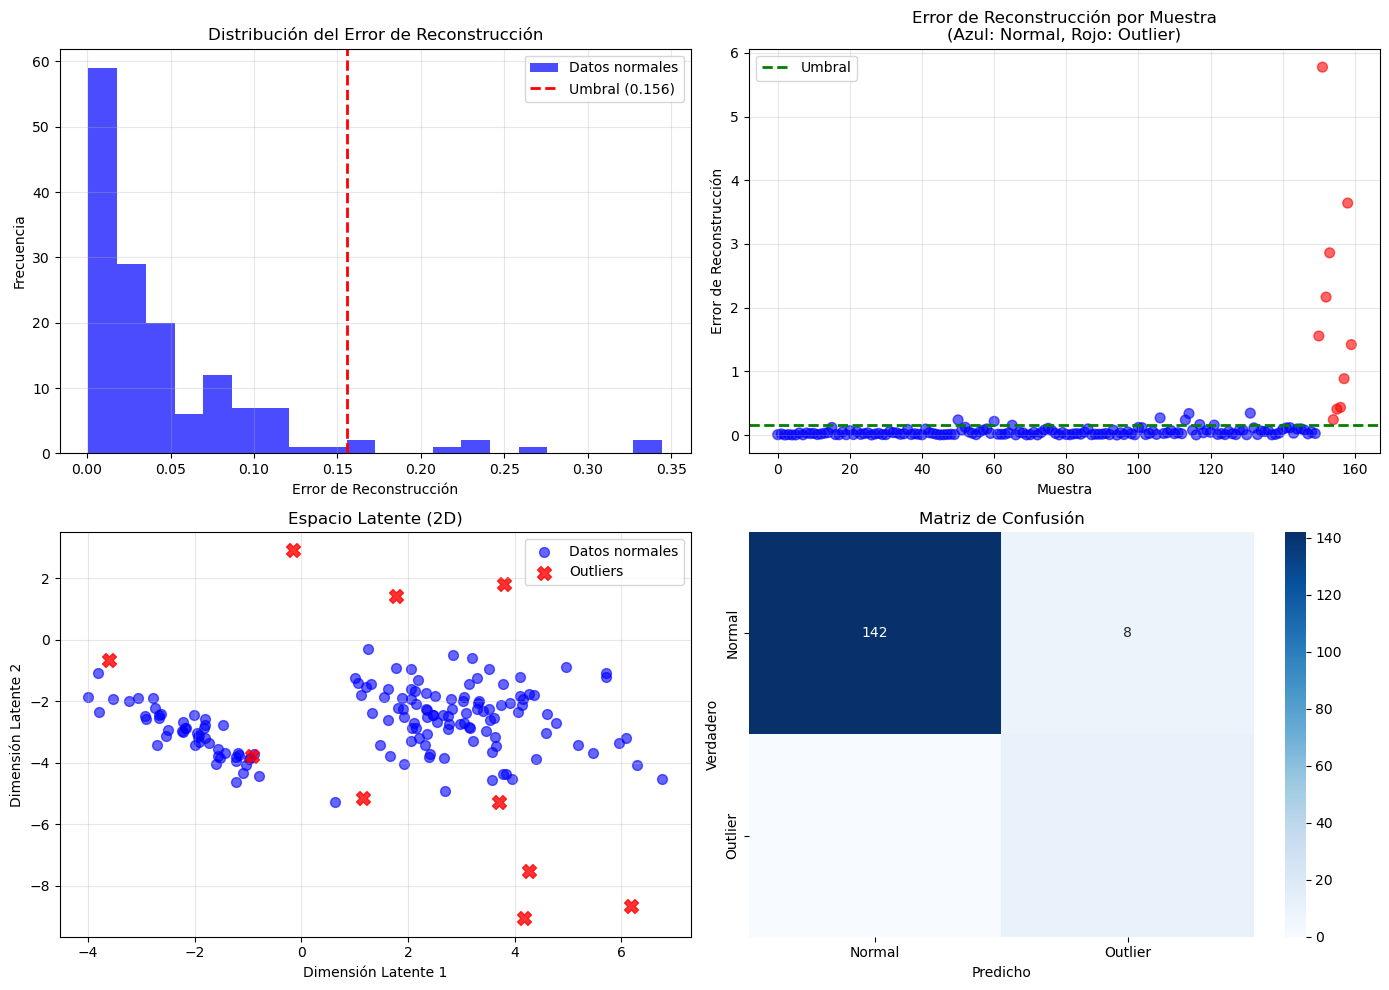

In [6]:
# ============================================
# 5. VISUALIZACIONES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de errores de reconstrucción
ax = axes[0, 0]
ax.hist(normal_errors, bins=20, alpha=0.7, label='Datos normales', color='blue')
ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Umbral ({threshold:.3f})')
ax.set_xlabel('Error de Reconstrucción')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del Error de Reconstrucción')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Error de reconstrucción por muestra
ax = axes[0, 1]
colors = ['blue' if y == 0 else 'red' for y in y_labels]
ax.scatter(range(len(reconstruction_errors)), reconstruction_errors, c=colors, alpha=0.6, s=50)
ax.axhline(threshold, color='green', linestyle='--', linewidth=2, label=f'Umbral')
ax.set_xlabel('Muestra')
ax.set_ylabel('Error de Reconstrucción')
ax.set_title('Error de Reconstrucción por Muestra\n(Azul: Normal, Rojo: Outlier)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Espacio latente (2D)
ax = axes[1, 0]
latent_np = latent_all.cpu().numpy()
colors_latent = ['blue' if y == 0 else 'red' for y in y_labels]
ax.scatter(latent_np[y_labels == 0, 0], latent_np[y_labels == 0, 1], 
           c='blue', alpha=0.6, s=50, label='Datos normales')
ax.scatter(latent_np[y_labels == 1, 0], latent_np[y_labels == 1, 1], 
           c='red', alpha=0.8, s=100, marker='X', label='Outliers')
ax.set_xlabel('Dimensión Latente 1')
ax.set_ylabel('Dimensión Latente 2')
ax.set_title('Espacio Latente (2D)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Matriz de confusión
ax = axes[1, 1]
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_labels, predicted_outliers)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Normal', 'Outlier'], 
            yticklabels=['Normal', 'Outlier'])
ax.set_ylabel('Verdadero')
ax.set_xlabel('Predicho')
ax.set_title('Matriz de Confusión')

plt.tight_layout()
plt.show()

In [7]:
# ============================================
# 6. DEMOSTRACIÓN CON NUEVAS MUESTRAS
# ============================================

print("=" * 60)
print("EJEMPLOS DE DETECCIÓN DE OUTLIERS")
print("=" * 60)

# Función para detectar si una nueva muestra es un outlier
def detect_outlier(sample, model, threshold, device):
    """
    Detecta si una muestra es un outlier
    Args:
        sample: numpy array con las características
        model: modelo del autoencoder
        threshold: umbral de error de reconstrucción
    Returns:
        is_outlier: booleano
        error: error de reconstrucción
    """
    sample_tensor = torch.FloatTensor(sample).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        reconstructed, _ = model(sample_tensor)
    error = torch.mean((sample_tensor - reconstructed) ** 2).item()
    is_outlier = error > threshold
    return is_outlier, error

# Ejemplos
print("\n1. Muestra NORMAL (del dataset de entrenamiento):")
sample_normal = X_scaled[0]
is_outlier, error = detect_outlier(sample_normal, model, threshold, device)
print(f"   Características: {sample_normal}")
print(f"   Error: {error:.4f}")
print(f"   ¿Es outlier?: {'SÍ' if is_outlier else 'NO'}")

print("\n2. Muestra OUTLIER (artificial extrema):")
sample_outlier = outliers[0]
is_outlier, error = detect_outlier(sample_outlier, model, threshold, device)
print(f"   Características: {sample_outlier}")
print(f"   Error: {error:.4f}")
print(f"   ¿Es outlier?: {'SÍ' if is_outlier else 'NO'}")

print("\n3. Muestra AMBIGUA (ligeramente fuera de rango):")
sample_ambigua = np.array([3.5, 3.5, 3.5, 3.5])  # valores altos pero no extremos
is_outlier, error = detect_outlier(sample_ambigua, model, threshold, device)
print(f"   Características: {sample_ambigua}")
print(f"   Error: {error:.4f}")
print(f"   ¿Es outlier?: {'SÍ' if is_outlier else 'NO'}")

EJEMPLOS DE DETECCIÓN DE OUTLIERS

1. Muestra NORMAL (del dataset de entrenamiento):
   Características: [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
   Error: 0.0065
   ¿Es outlier?: NO

2. Muestra OUTLIER (artificial extrema):
   Características: [-1.00367905  3.60571445  1.85595153  0.78926787]
   Error: 1.5556
   ¿Es outlier?: SÍ

3. Muestra AMBIGUA (ligeramente fuera de rango):
   Características: [3.5 3.5 3.5 3.5]
   Error: 0.9950
   ¿Es outlier?: SÍ
